# Credit Risk Model
### Pipeline : Analyse → Feature Engineering → Modélisation → Export

## 1. Imports & Configuration

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Options d'affichage
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 2. Chargement des données


In [9]:
# ⚙️ Modifiez ce chemin selon l'emplacement de votre fichier
CSV_PATH = 'german_credit_data.csv'

df = pd.read_csv(CSV_PATH)
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


## 3. Exploration initiale

In [10]:
print('Shape:', df.shape)
df.info()

Shape: (1000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [11]:
# Résumé statistique (colonnes numériques ET catégorielles)
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Distribution de la cible
print(df['Risk'].value_counts())
print()
print('Pourcentages :')
print((df['Risk'].value_counts(normalize=True) * 100).round(2))

Risk
good    700
bad     300
Name: count, dtype: int64

Pourcentages :
Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64


In [13]:
# Valeurs manquantes
print('Valeurs manquantes par colonne :')
print(df.isna().sum())

Valeurs manquantes par colonne :
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


In [14]:
# Lignes dupliquées
print('Lignes dupliquées :', df.duplicated().sum())

Lignes dupliquées : 0


## 4. Nettoyage des données

In [15]:
# Suppression de la colonne index inutile (si présente)
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Suppression des lignes avec valeurs manquantes
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Shape après nettoyage:', df.shape)

Shape après nettoyage: (522, 10)


## 5. Analyse univariée — Variables numériques

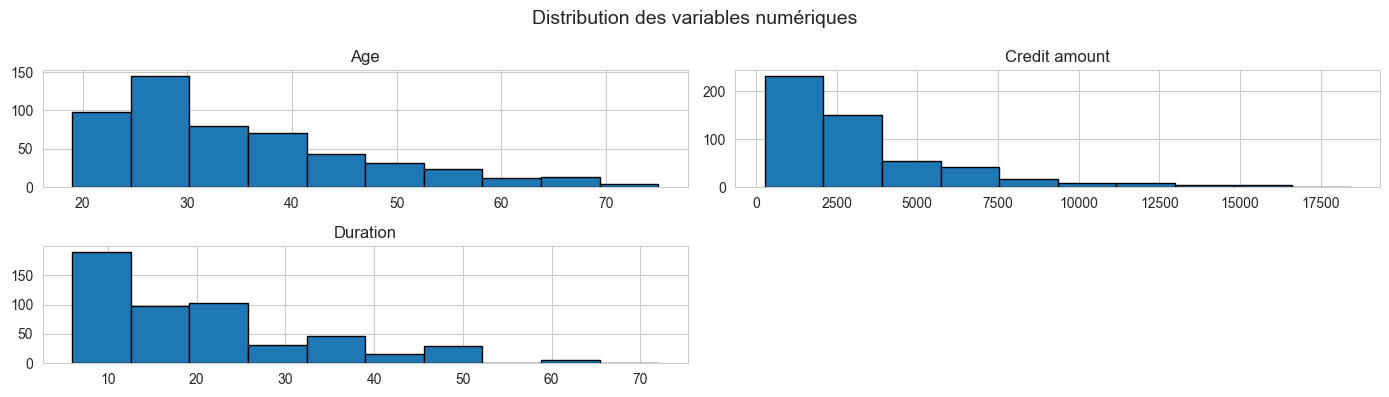

In [16]:
numerical_cols = ['Age', 'Credit amount', 'Duration']

# Histogrammes
df[numerical_cols].hist(bins=10, edgecolor='black', figsize=(14, 4))
plt.suptitle('Distribution des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

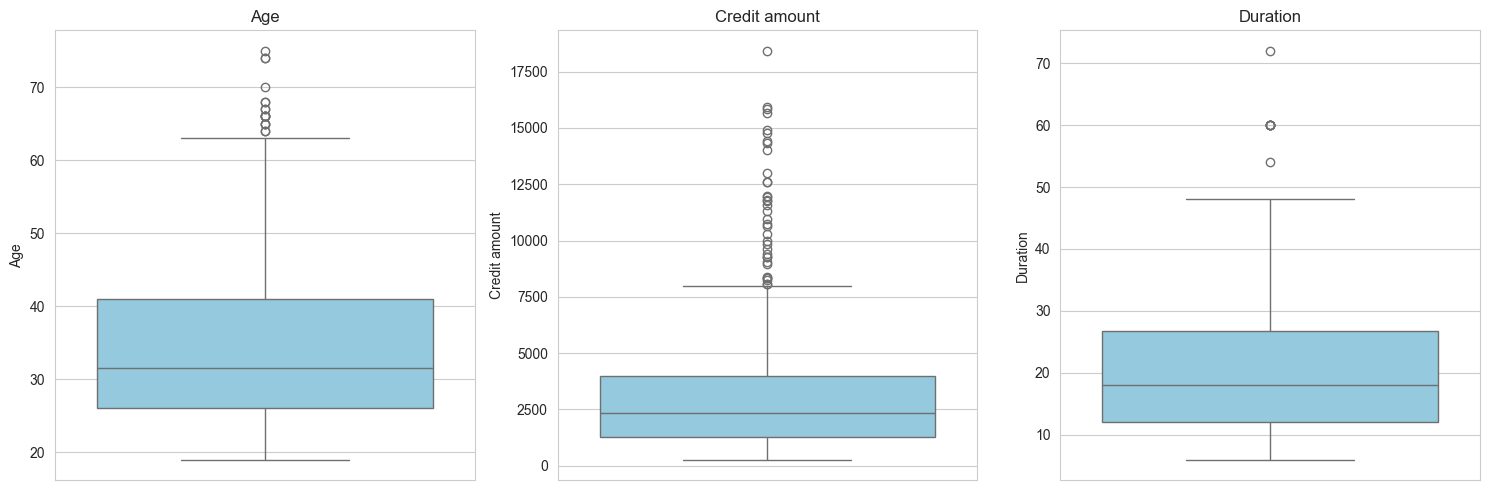

In [17]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], color='skyblue', ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## 6. Analyse univariée — Variables catégorielles

C:\Users\cleme\AppData\Local\Temp\ipykernel_10436\2013015948.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='Set2', ax=axes[i])
C:\Users\cleme\AppData\Local\Temp\ipykernel_10436\2013015948.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='Set2', ax=axes[i])
C:\Users\cleme\AppData\Local\Temp\ipykernel_10436\2013015948.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='Set2', ax=axes[i])
C:\Users\cleme\AppData\Local\Te

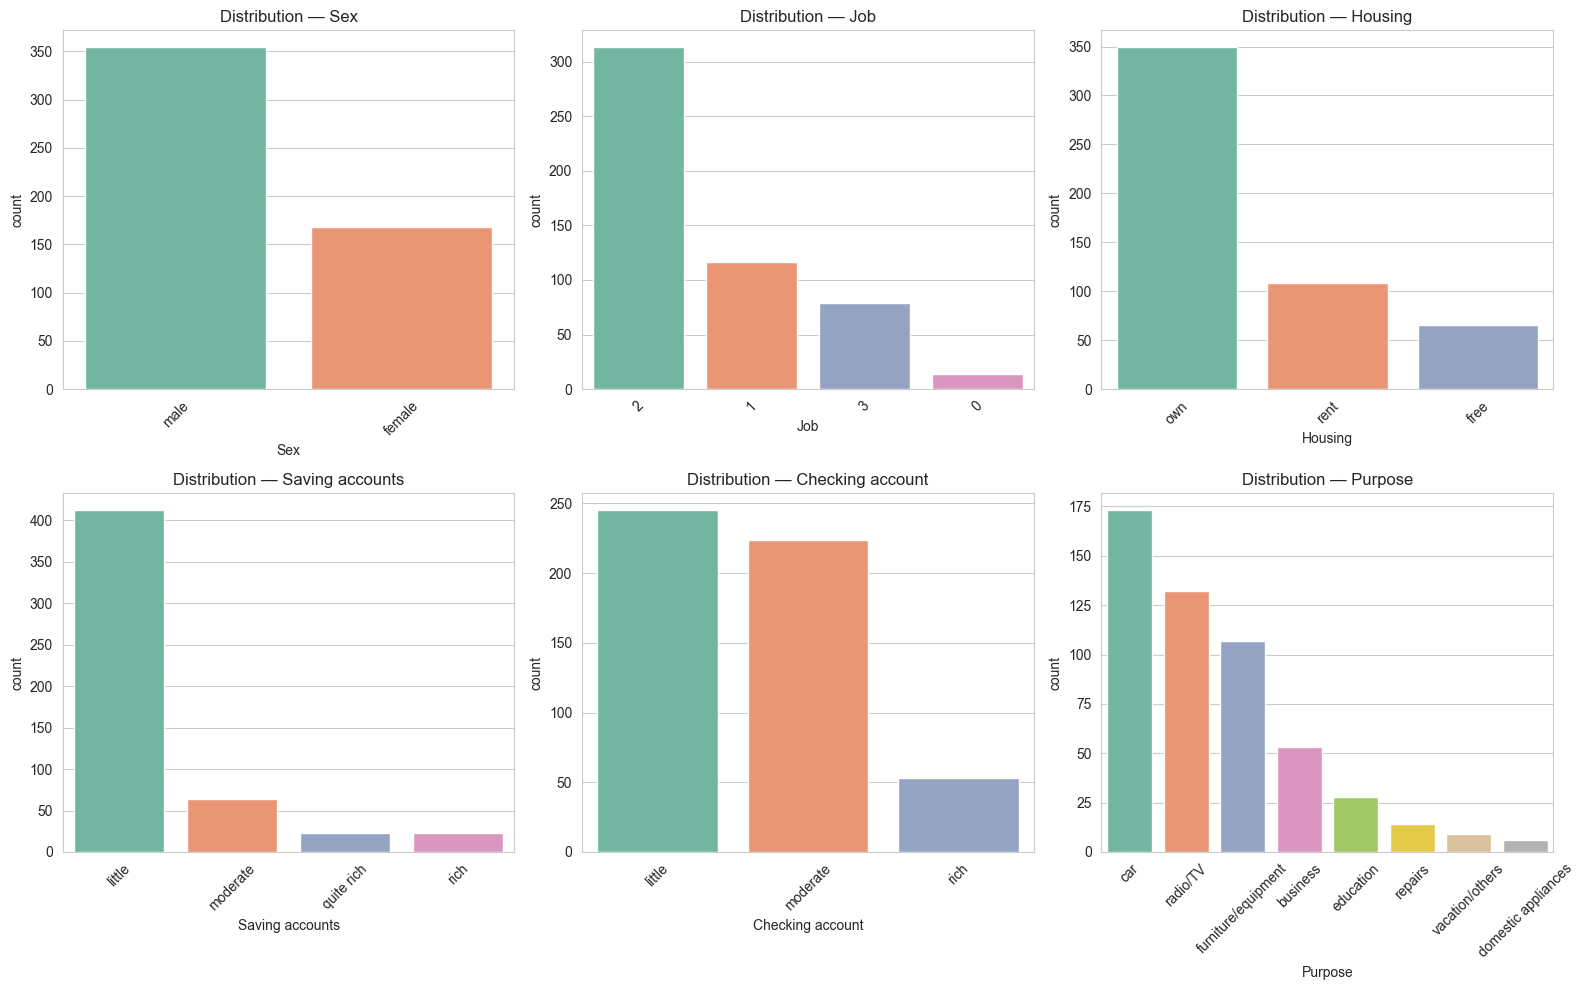

In [18]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Distribution — {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Matrice de corrélation

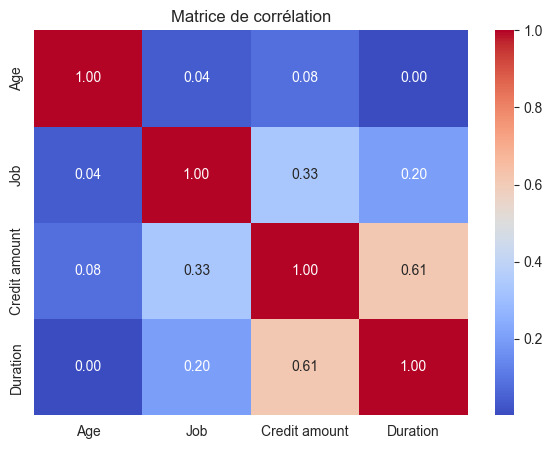

In [19]:
corr = df[['Age', 'Job', 'Credit amount', 'Duration']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

## 8. Analyses croisées

In [20]:
# Montant moyen par type de job
print('Montant moyen par Job :')
print(df.groupby('Job')['Credit amount'].mean())

print()
print('Montant moyen par Sex :')
print(df.groupby('Sex')['Credit amount'].mean())

Montant moyen par Job :
Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

Montant moyen par Sex :
Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64


In [21]:
# Tableau croisé : Montant crédit vs Housing & Purpose
pd.pivot_table(df, values='Credit amount', index='Housing', columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


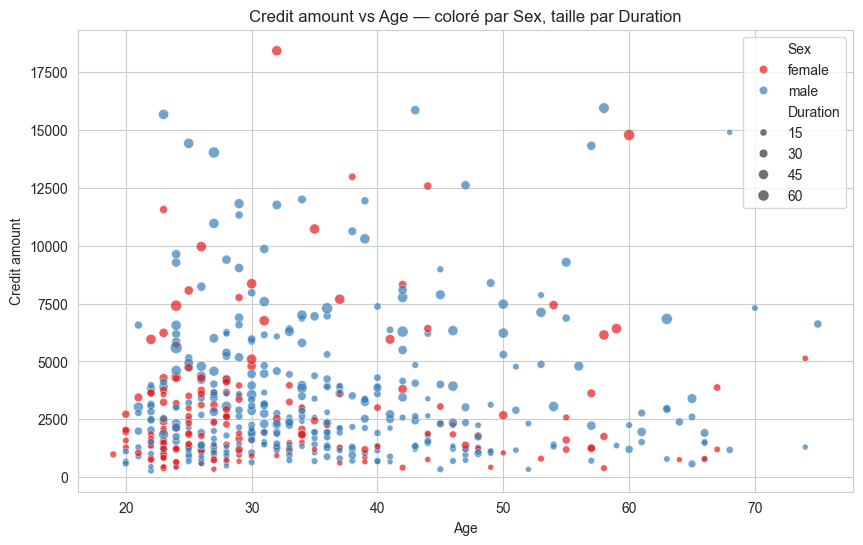

In [22]:
# Scatter : Age vs Credit amount (couleur=Sex, taille=Duration)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x='Age', y='Credit amount',
    hue='Sex', size='Duration',
    alpha=0.7, palette='Set1'
)
plt.title('Credit amount vs Age — coloré par Sex, taille par Duration')
plt.show()

C:\Users\cleme\AppData\Local\Temp\ipykernel_10436\3282541025.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Saving accounts', y='Credit amount', palette='Pastel1')


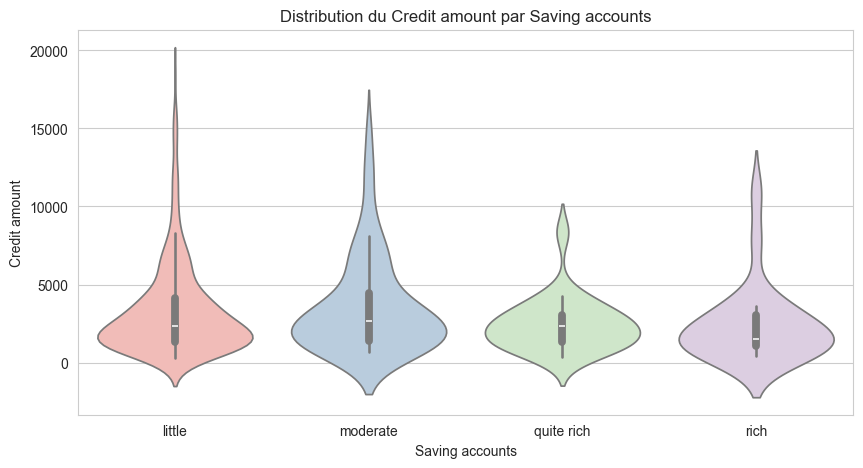

In [23]:
# Violin plot : distribution Credit amount par Saving accounts
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='Saving accounts', y='Credit amount', palette='Pastel1')
plt.title('Distribution du Credit amount par Saving accounts')
plt.show()

## 9. Analyse par rapport au Risque

C:\Users\cleme\AppData\Local\Temp\ipykernel_10436\1226687160.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2', ax=axes[i])
C:\Users\cleme\AppData\Local\Temp\ipykernel_10436\1226687160.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2', ax=axes[i])
C:\Users\cleme\AppData\Local\Temp\ipykernel_10436\1226687160.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2', ax=axes[i])


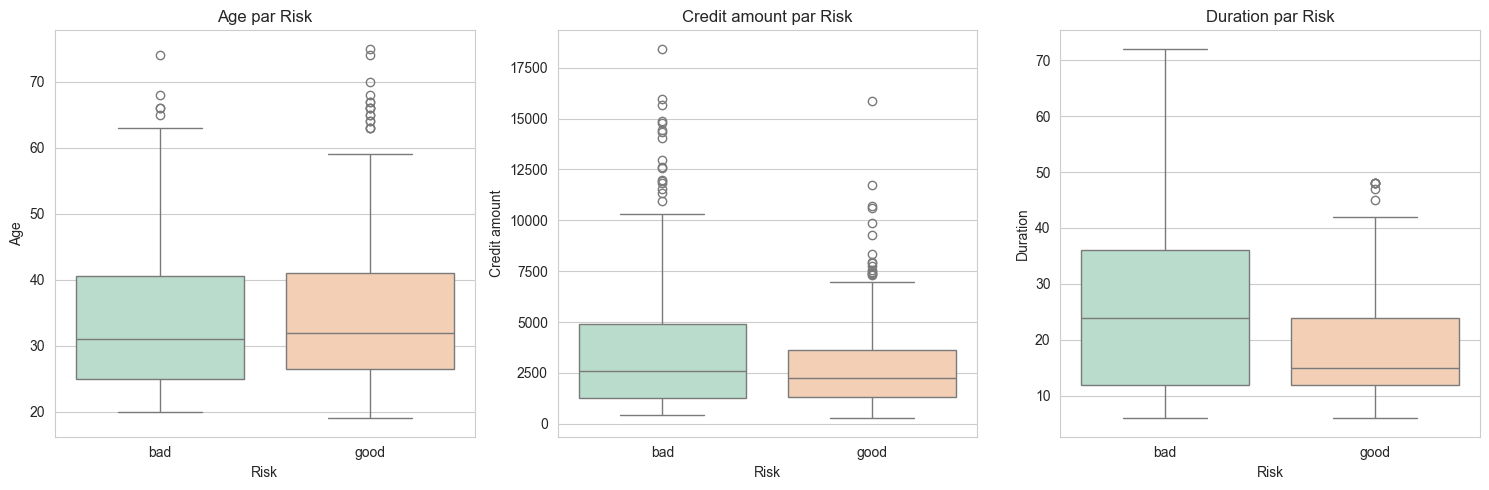

In [24]:
# Boxplots numériques par Risk
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2', ax=axes[i])
    axes[i].set_title(f'{col} par Risk')
plt.tight_layout()
plt.show()

In [25]:
# Moyennes par groupe de Risk
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


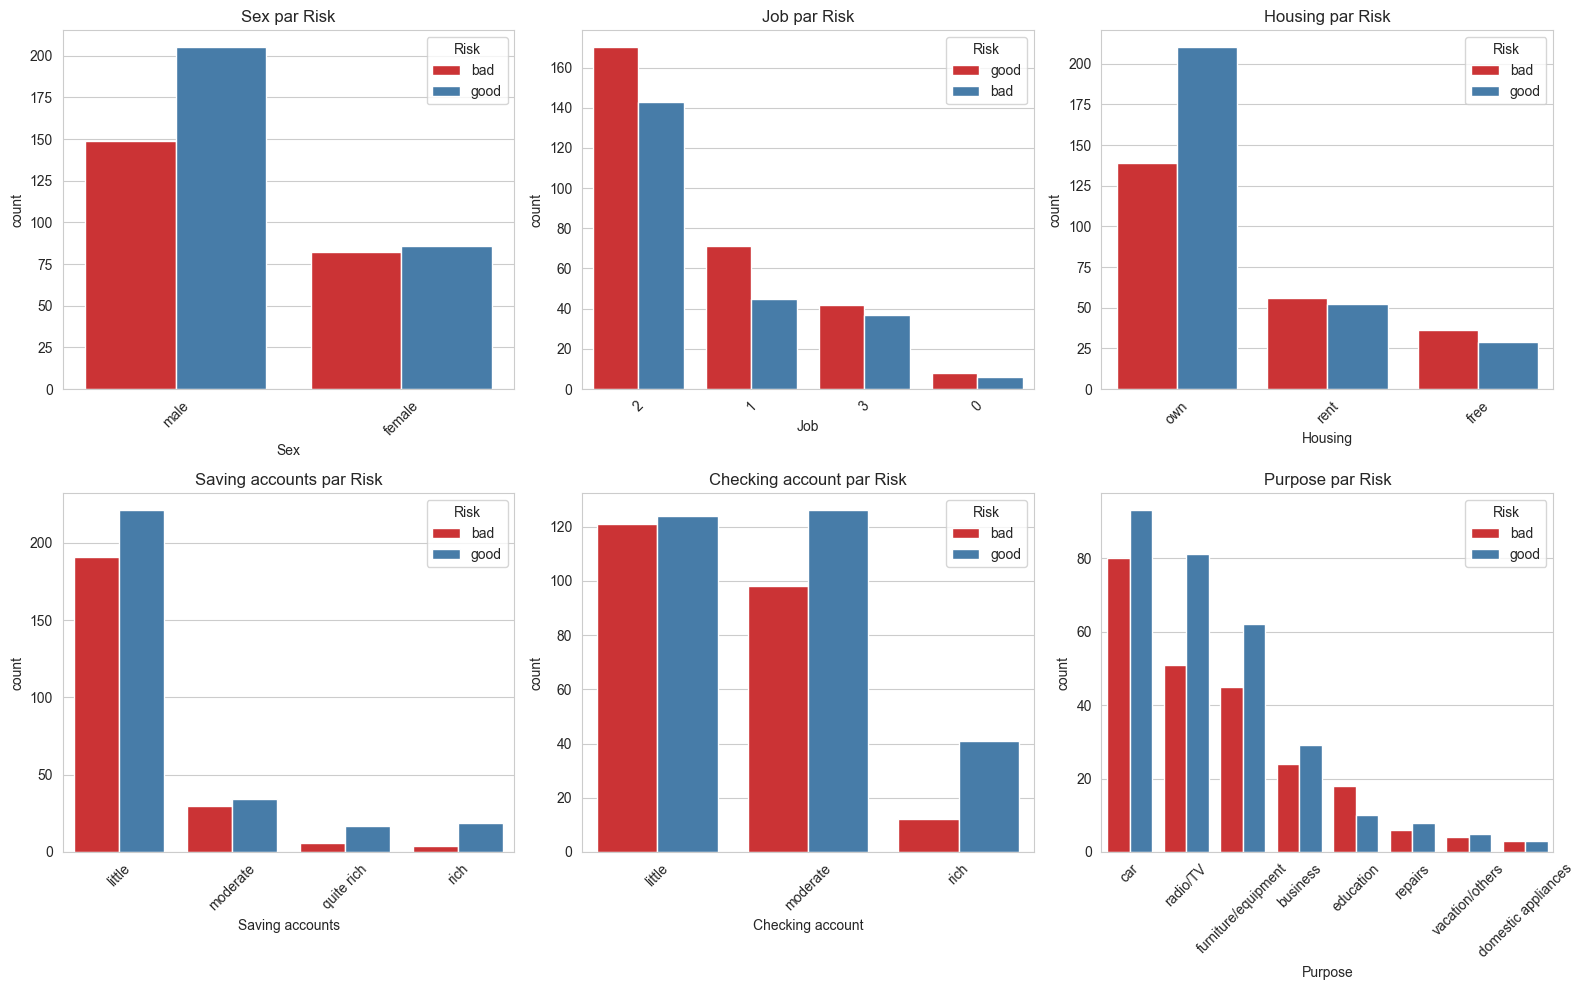

In [26]:
# Countplots catégoriels par Risk
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue='Risk', order=order, palette='Set1', ax=axes[i])
    axes[i].set_title(f'{col} par Risk')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Feature Engineering & Encodage

In [32]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Sélection des features et de la cible
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration']
target = 'Risk'

df_model = df[features + [target]].copy()
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [33]:
# Encodage des variables catégorielles (hors cible)
cat_cols_to_encode = df_model.select_dtypes(include='object').drop(columns=[target]).columns.tolist()
print('Colonnes à encoder :', cat_cols_to_encode)

label_encoders = {}
for col in cat_cols_to_encode:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    joblib.dump(le, f'{col}_encoder.pkl')
    print(f'  ✅ {col} encodé et sauvegardé')

Colonnes à encoder : ['Sex', 'Housing', 'Saving accounts', 'Checking account']
  ✅ Sex encodé et sauvegardé
  ✅ Housing encodé et sauvegardé
  ✅ Saving accounts encodé et sauvegardé
  ✅ Checking account encodé et sauvegardé


In [34]:
# Encodage de la cible : good=1, bad=0
le_target = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target])
joblib.dump(le_target, 'target_encoder.pkl')

print('Classes :', le_target.classes_)  # 0=bad (haut risque), 1=good (faible risque)
df_model[target].value_counts()

Classes : ['bad' 'good']


Risk
1    291
0    231
Name: count, dtype: int64

In [35]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


## 11. Split Train / Test

In [36]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (417, 8)
X_test : (105, 8)


## 12. Entraînement & Tuning des modèles

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    """Entraîne un modèle avec GridSearchCV et retourne le meilleur estimateur."""
    grid = GridSearchCV(
        model, param_grid,
        cv=5, scoring='accuracy', n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return best_model, accuracy, grid.best_params_

In [41]:
# --- Decision Tree ---
dt = DecisionTreeClassifier(random_state=1, class_weight='balanced')
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
best_dt, acc_dt, params_dt = train_model(dt, dt_params, X_train, y_train, X_test, y_test)
print(f'Decision Tree  → Accuracy : {acc_dt:.4f}')
print(f'Meilleurs paramètres : {params_dt}')

Decision Tree  → Accuracy : 0.5810
Meilleurs paramètres : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [42]:
# --- Random Forest ---
rf = RandomForestClassifier(random_state=1, class_weight='balanced', n_jobs=-1)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
best_rf, acc_rf, params_rf = train_model(rf, rf_params, X_train, y_train, X_test, y_test)
print(f'Random Forest  → Accuracy : {acc_rf:.4f}')
print(f'Meilleurs paramètres : {params_rf}')

Random Forest  → Accuracy : 0.6190
Meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [43]:
# --- Extra Trees ---
et = ExtraTreesClassifier(random_state=1, class_weight='balanced', n_jobs=-1)
et_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
best_et, acc_et, params_et = train_model(et, et_params, X_train, y_train, X_test, y_test)
print(f'Extra Trees    → Accuracy : {acc_et:.4f}')
print(f'Meilleurs paramètres : {params_et}')

Extra Trees    → Accuracy : 0.6476
Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [44]:
# --- XGBoost ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    random_state=1,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_params, X_train, y_train, X_test, y_test)
print(f'XGBoost        → Accuracy : {acc_xgb:.4f}')
print(f'Meilleurs paramètres : {params_xgb}')

XGBoost        → Accuracy : 0.6762
Meilleurs paramètres : {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


c:\Users\cleme\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:28:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 13. Comparaison des modèles

       Modèle  Accuracy
      XGBoost  0.676190
  Extra Trees  0.647619
Random Forest  0.619048
Decision Tree  0.580952


C:\Users\cleme\AppData\Local\Temp\ipykernel_10436\1664904735.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Modèle', y='Accuracy', palette='viridis')


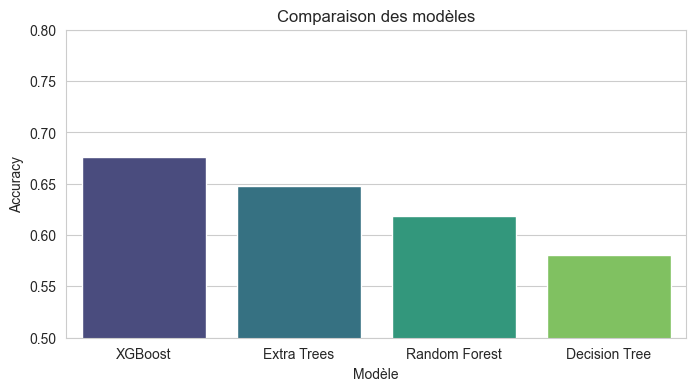

In [45]:
results = pd.DataFrame({
    'Modèle': ['Decision Tree', 'Random Forest', 'Extra Trees', 'XGBoost'],
    'Accuracy': [acc_dt, acc_rf, acc_et, acc_xgb]
}).sort_values('Accuracy', ascending=False)

print(results.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=results, x='Modèle', y='Accuracy', palette='viridis')
plt.ylim(0.5, 0.8)
plt.title('Comparaison des modèles')
plt.show()

## 14. Export du meilleur modèle

In [46]:
# Export du meilleur modèle (Extra Trees selon la vidéo)
joblib.dump(best_et, 'extra_trees_credit_model.pkl')
print('✅ Modèle sauvegardé : extra_trees_credit_model.pkl')

# Vérification rapide
sample_pred = best_et.predict(X_test[:5])
print('Prédictions test (5 premiers) :', sample_pred)
print('Valeurs réelles               :', y_test.values[:5])

✅ Modèle sauvegardé : extra_trees_credit_model.pkl
Prédictions test (5 premiers) : [1 1 1 1 1]
Valeurs réelles               : [0 1 0 1 1]


Pour lancer l'application il faut taper la commande suivante dans le terminal "py -m streamlit run app.py" en ayant un environnement python d'installer